# Working with remote data, fully lazily

In this demo and exercise, we will showcase an advantage of `dask` beyond arbitrary slicing. We will show how dask can be used to load remote array data lazily, do some simple processing, and store parts of it on disk in a chunked file format called `zarr`.

In [1]:
from IPython.core.magic import register_cell_magic
from IPython.display import display
import threading, time, tracemalloc

@register_cell_magic
def monitor(_, cell):
    tracemalloc.start()
    start = time.time()
    stop_event = threading.Event()
    handle = display("starting...", display_id=True)

    def report_loop():
        while not stop_event.wait(0.5):  # poll every 0.5s
            current, peak = tracemalloc.get_traced_memory()
            elapsed = time.time() - start
            handle.update(f"[t={elapsed:6.2f}s] current={current/1e6:.1f}MB peak={peak/1e6:.1f}MB")

    t = threading.Thread(target=report_loop, daemon=True)
    t.start()
    try:
        get_ipython().run_cell(cell)
    finally:
        stop_event.set()
        t.join()

    elapsed = time.time() - start
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"\n--- Monitoring report ---")
    print(f"[memory] current: {current/1e6:.1f} MB, peak: {peak/1e6:.1f} MB")
    print(f"[speed] time elapsed: {elapsed:.3f}s")

Our example data this time comes from live two-photon microscopy. In a nutshell, it's a long video (40'000 frames) from a small microscope implanted into the skull of a mouse. The mouse neurons fluoresce when they are active, resulting in brighter pixels in the video. It is a public dataset hosted on the DANDI archive, part of a larger effort called the MIcrONS project. We can open the remote file using a helper function...


In [2]:
%%monitor

from pathlib import Path
import importlib
import sys

helper_path = Path.cwd() / "remote_data_helper.py"
spec = importlib.util.spec_from_file_location("utils", helper_path)
assert spec is not None and spec.loader is not None
helper = importlib.util.module_from_spec(spec)
spec.loader.exec_module(helper)

sys.modules["helper_module"] = helper

import helper_module

print(f"Loaded helper from: {helper_path}")
print(f"Python platform: {sys.platform}")


'[t=  5.14s] current=77.6MB peak=78.0MB'

Loaded helper from: /Users/alessandrofelder/dev/slides-large-array-data-osss-2026/notebooks/remote_data_helper.py
Python platform: darwin

--- Monitoring report ---
[memory] current: 79.2 MB, peak: 79.4 MB
[speed] time elapsed: 5.377s


In [3]:
%%monitor

from helper_module import open_remote_file


DANDISET_ID = "000402"
ASSET_PATH = "sub-17797/sub-17797_ses-6-scan-4_behavior+image+ophys.nwb"
remote_file, io = open_remote_file(dandiset_id = DANDISET_ID, asset_path = ASSET_PATH)

'[t= 18.40s] current=11.2MB peak=11.2MB'

Resolved S3 URL: https://dandiarchive.s3.amazonaws.com/blobs/d25/a26/d25a268a-73d5-41bf-994a-7b7fc3f0eb17

--- Monitoring report ---
[memory] current: 11.4 MB, peak: 11.5 MB
[speed] time elapsed: 18.745s


... and print some metadata about it..

In [4]:
%%monitor

print("\n--- Session info ---")
print("Session description:", remote_file.session_description)
print("Session start time:", remote_file.session_start_time)
print("Subject:", remote_file.subject)

print("\n--- Acquisition (lazy) ---")
for name, ts in remote_file.acquisition.items():
    print(f"acquisition/{name}: shape={getattr(ts, 'data', None) and ts.data.shape}")

'starting...'


--- Session info ---
Session description: Contains calcium imaging recorded from multiple cortical visual areas and behavioral measurements while a mouse viewed natural movies and parametric stimuli. The structural ids are added as plane segmentation columns from the CAVE database on 2023-02-12. To access the latest revision see the notebook that is linked to the dandiset. The structural ids might not be present for all plane segmentations.
Session start time: 2018-03-06 00:00:00+00:00
Subject: subject pynwb.file.Subject at 0x4562650176
Fields:
  age: P75D/P81D
  sex: M
  species: Mus musculus
  subject_id: 17797


--- Acquisition (lazy) ---
acquisition/EyeTracking: shape=None
acquisition/PupilTracking: shape=None
acquisition/TwoPhotonSeries1: shape=(40000, 248, 440)
acquisition/TwoPhotonSeries2: shape=(40000, 248, 440)
acquisition/TwoPhotonSeries3: shape=(40000, 248, 440)
acquisition/TwoPhotonSeries4: shape=(40000, 248, 440)
acquisition/TwoPhotonSeries5: shape=(40000, 248, 440)
acqui

We note that there are 8 acquisitions called `TwoPhotonSeries` in the dataset, which seem to be arrays of shape (40000, 248,440). The fourth will be our example data for now. We can read it into a Python variable:

In [5]:
%%monitor

two_photon_series = remote_file.acquisition["TwoPhotonSeries4"]


'starting...'


--- Monitoring report ---
[memory] current: 0.0 MB, peak: 0.0 MB
[speed] time elapsed: 0.005s


Let's explore the array in more detail

In [14]:
%%monitor

from helper_module import in_raw_gb


print(type(two_photon_series))
print(type(two_photon_series.data))
in_raw_gb(two_photon_series.data)
print(two_photon_series.data.chunks)


'starting...'

<class 'pynwb.ophys.TwoPhotonSeries'>
<class 'h5py._hl.dataset.Dataset'>
8.13 GiB
(2254, 14, 14)

--- Monitoring report ---
[memory] current: 0.0 MB, peak: 0.1 MB
[speed] time elapsed: 0.046s


In [7]:

import dask.array as da

streamed_imaging = da.from_array(two_photon_series.data, chunks=two_photon_series.data.chunks)


In [8]:
%%monitor
time_slice = (slice(50,550))

'starting...'


--- Monitoring report ---
[memory] current: 0.0 MB, peak: 0.0 MB
[speed] time elapsed: 0.003s


In [9]:
%%monitor
print(streamed_imaging.shape)
average = streamed_imaging[time_slice].mean(axis=0)
print(average.shape)

in_raw_gb(streamed_imaging)

print(streamed_imaging.chunksize)

'starting...'

(40000, 248, 440)
(248, 440)
8.13 GiB
(2254, 14, 14)

--- Monitoring report ---
[memory] current: 0.7 MB, peak: 0.7 MB
[speed] time elapsed: 0.041s


In [10]:
%%monitor
average_np = average.compute()


'[t=138.18s] current=409.9MB peak=410.6MB'


--- Monitoring report ---
[memory] current: 407.7 MB, peak: 411.6 MB
[speed] time elapsed: 138.554s


'[t=  8.72s] current=27.9MB peak=40.6MB'

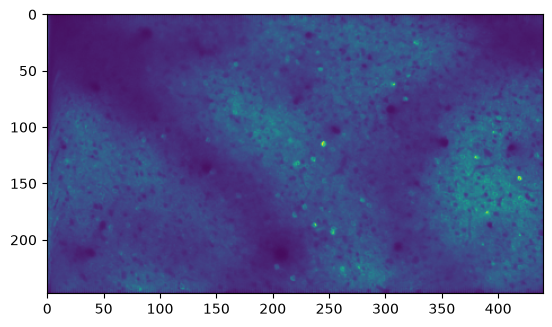


--- Monitoring report ---
[memory] current: 28.6 MB, peak: 41.3 MB
[speed] time elapsed: 9.187s


In [11]:
%%monitor
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(average_np)
plt.show()


In [12]:
%%monitor
# write to local temp store
from pathlib import Path
out_path = Path("./twophoton_series.zarr")

array = streamed_imaging[time_slice]
print(array.chunksize)
array.to_zarr(out_path, overwrite=True)

average.to_zarr(Path("./average.zarr"),overwrite=True)

io.close()



'[t=  8.70s] current=10.3MB peak=11.4MB'

(500, 14, 14)

--- Monitoring report ---
[memory] current: 7.0 MB, peak: 11.7 MB
[speed] time elapsed: 9.077s


## Stretch exercise

Try combining several `TwoPhotonSeries` lazily into the same dask array, in a new dimension (depth). This will result in a 3D video. Hint: Use `da.stack`.

Alternatively, feel free to try out some of the concepts presented here on your own data, invent your own related stretch exercise or help others in the room.

## Key take-aways

* 